# 1. Importação de bibliotecas

In [1]:
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt

# Modelagem
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

# 2. Carregando os dados

In [2]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 3. Exploração inicial

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# 4. Análise Exploratória (EDA)

## Distribuição da variável alvo

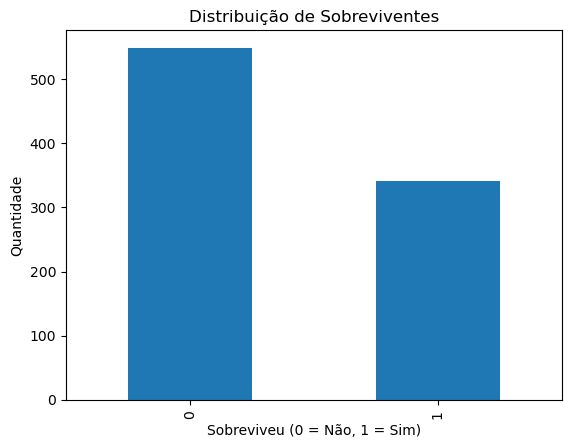

In [6]:
plt.figure()
df['Survived'].value_counts().plot(kind='bar')
plt.title("Distribuição de Sobreviventes")
plt.xlabel("Sobreviveu (0 = Não, 1 = Sim)")
plt.ylabel("Quantidade")
plt.show()

## Sobrevivência por sexo

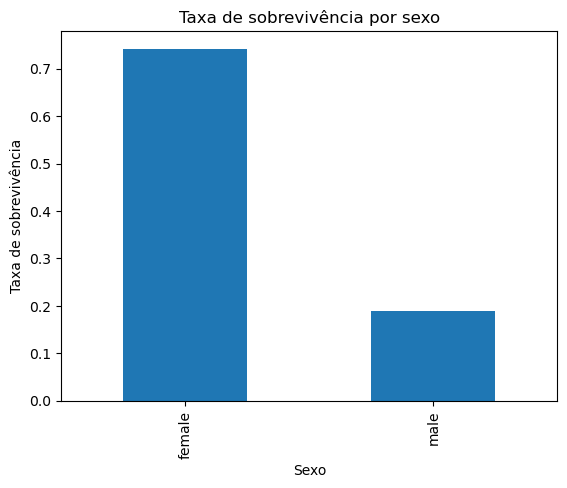

In [7]:
survival_by_sex = df.groupby('Sex')['Survived'].mean()

plt.figure()
survival_by_sex.plot(kind='bar')
plt.title("Taxa de sobrevivência por sexo")
plt.xlabel("Sexo")
plt.ylabel("Taxa de sobrevivência")
plt.show()

## Sobrevivência por classe

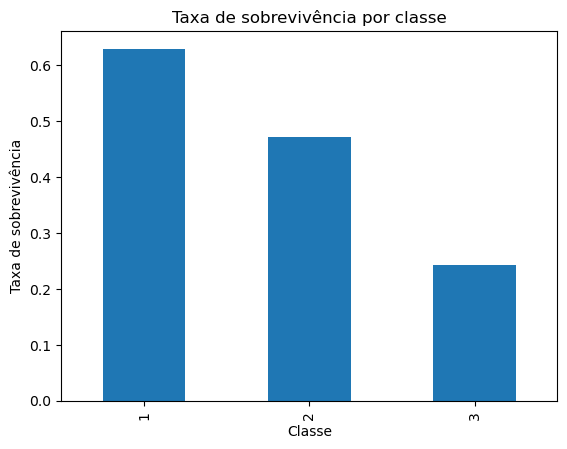

In [8]:

survival_by_class = df.groupby('Pclass')['Survived'].mean()

plt.figure()
survival_by_class.plot(kind='bar')
plt.title("Taxa de sobrevivência por classe")
plt.xlabel("Classe")
plt.ylabel("Taxa de sobrevivência")
plt.show()


## Correlação

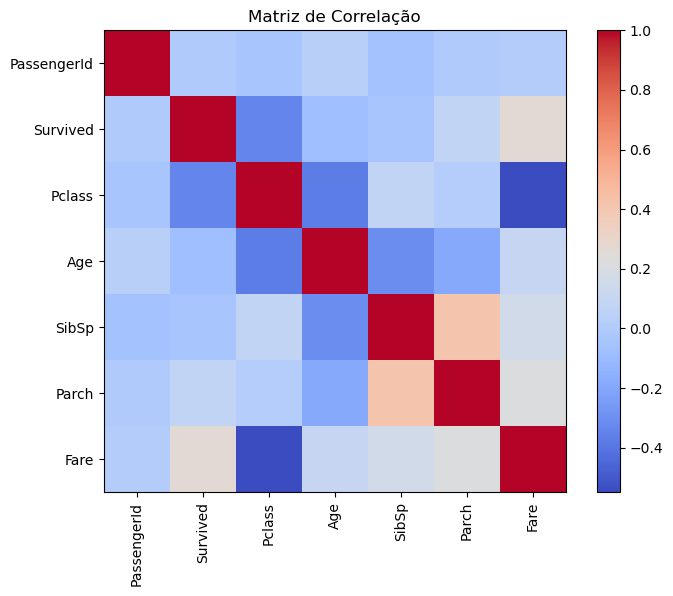

In [9]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Matriz de Correlação")
plt.show()

# 5. Pré-processamento

## Tratamento de nulos

In [10]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

df.drop(columns=['Cabin'], inplace=True)

## Encoding

In [11]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

## Remoção de colunas irrelevantes

In [12]:
df.drop(columns=['Name', 'Ticket', 'PassengerId'], inplace=True)

# 6. Separação dos dados

In [13]:
X = df.drop('Survived', axis=1)
y = df['Survived']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7. Normalização

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 8. Treinamento

In [16]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# 9. Predição

In [17]:
y_pred = model.predict(X_test)

# 10. Avaliação

## Acurácia

In [18]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia: {accuracy:.4f}")

Acurácia: 0.8101


## Matriz de confusãocm = confusion_matrix(y_test, y_pred)


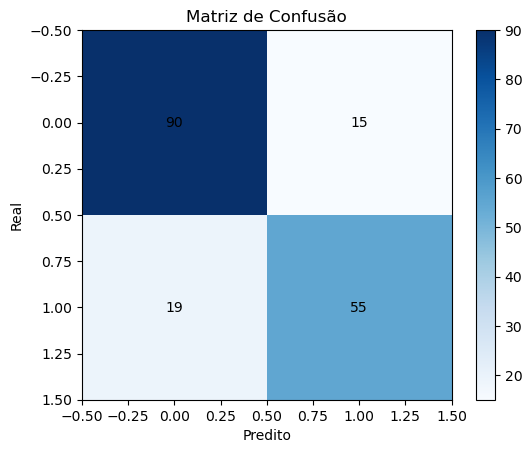

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm, cmap='Blues')
plt.title("Matriz de Confusão")
plt.colorbar()

plt.xlabel("Predito")
plt.ylabel("Real")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

## Relatório

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

